This notebook records the creation of the `SHENDURE_BOUNDS` preset object and some plots illustrating modeling choices.

Setup.

In [ ]:
import scMPRAforge as scm
#load the autoreload extension
%load_ext autoreload
#reload code on every execution
#(this may break objects)
#you can remove this & do dev in a notebook, then paste into the module when you are done.
%autoreload 2

In [ ]:
from dask.distributed import Client, LocalCluster
cluster=LocalCluster(memory_limit='8GB')
client=Client(cluster)

2025-08-31 16:06:52,294 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:39725' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'lambda-94a4ae1a08276a75987107b28e78a69a', 'lambda-a39aef3b840aaa7655b75642071080b2', 'lambda-2bb7757f1acb1eac9031933517a5d745', 'lambda-c6cc70e296ddc52c7500e130ed74f991', 'lambda-fe7ed8a203084eb28dde418928c81240', 'lambda-2df53feee706bd8f6b550e33f99620fa', 'lambda-a5125db63df44bc9c03ed2a059ab4fd3', 'lambda-6c21e4e0ed9cea2f91becbf80be981b5', 'lambda-ccf3cf58fcdab517c0700c87f1272129', 'lambda-d34a158b8262d5f293a8c6c284964a14', 'lambda-184ee23da43990598430bf91c9057c47', 'lambda-05a5aaea68bbde621b3e295eb15abbee', 'lambda-c700ca81a785741223831c21a0a9873c', 'lambda-67455cf98be66eb50efbc1c4b926d8b4', 'lambda-98f26459bffca8bb4eef897abf4d4fe5', 'lambda-b25ed8eaf91ce03c1d1e4b604881c504', 'lambda-4a3caaeb7d3ecdde8b2284f4f15d2427', 'lambda-9dc6a72f4b6c4a853b90bf1dd7d2aafb', 'lambda-9b54ab6da1dd8093d7c4e7c517ce

Load shendure ortho object.

In [2]:
path="/gpfs/gibbs/pi/reilly/tabula_data/shendure"
name="ortho_primordial_v3"
data_root="/gpfs/gibbs/pi/reilly/tabula_data"
primordial=scm.ortho.load(client,path,name)

Create the bounds

In [3]:
shendure_bounds=scm.Bounds.from_ortho(primordial)

Let's make some plots showing why we chose nb:

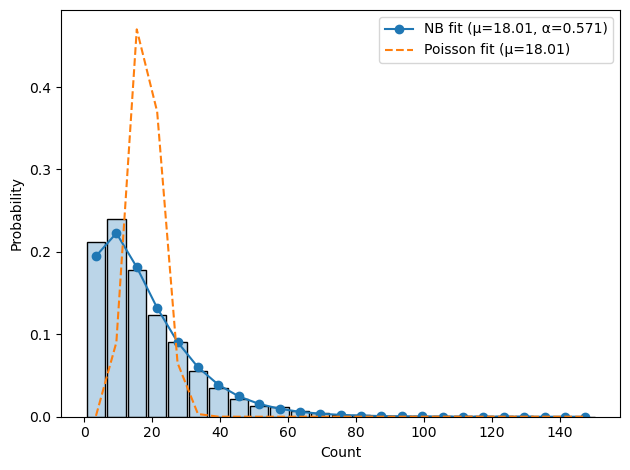

In [8]:
shendure_bounds.transfection_model.plot()

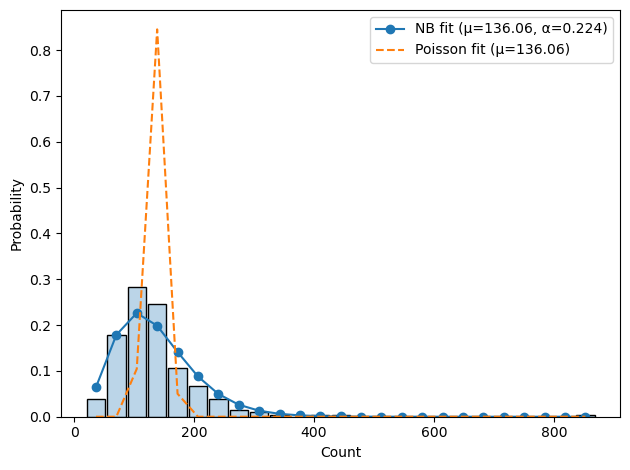

In [9]:
shendure_bounds.library_model.plot()

Now let's save the object:

In [10]:
shendure_bounds.to_tgz("scMPRAforge/presets/shendure_bounds.tgz")

In [11]:
cluster.close()